<a href="https://colab.research.google.com/github/faezesarlakifar/APAI-project-work/blob/main/cost_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Efective instructions cost analysis

1. **Two ESM-2 checkpoints** (35M + 150M): so cost curves can be compared across model size as well as sequence length.

2. **A longer sequence length** (up to 8192): the quadratic-vs-linear gap barely shows below ~1024, so this range is where it actually becomes visible.

3. **An RMT wrapper** implementing the segment-recurrent inference algorithm from the theoretical cost-analysis note: fixed-size blocks + a small carried memory state, instead of full self-attention over the whole sequence.

## 1. Install dependencies

In [1]:
!pip install -q torch transformers fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.5 MB/s eta 0:00:00


## 2. Imports and setup

In [2]:
import warnings
import logging
from typing import Dict, List, Optional

import torch
import torch.nn as nn
from transformers import AutoModel
from fvcore.nn import FlopCountAnalysis

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.getLogger("fvcore").setLevel(logging.ERROR)


## 3. RMT wrapper

Segment-recurrent (RMT-style) wrapper around a pretrained ESM-2 encoder.

Splits the input into fixed-size blocks and carries a small set of learned memory
tokens across blocks (prepended to each block's real token embeddings), instead of
running full self-attention over the whole sequence at once. Matches the
`RMT_Inference` pseudocode from the theoretical cost-analysis note: memory state
`Mem_t` is updated each block and carried to block `t+1`.

Uses `inputs_embeds`, which is documented public API on `EsmModel` (checked against
the actual `transformers` source rather than guessed), plus `model.embeddings.
word_embeddings` and `model.config.hidden_size` — both stable across versions, so
this doesn't reach into undocumented internals.

In [3]:
class RMTWrapper(nn.Module):
    def __init__(self, base_model: nn.Module, block_size: int = 128, num_memory_tokens: int = 8):
        super().__init__()
        self.base_model = base_model
        self.block_size = block_size
        self.num_memory_tokens = num_memory_tokens
        hidden_size = base_model.config.hidden_size
        # learned initial memory state; broadcast across batch at forward time
        self.memory_init = nn.Parameter(torch.randn(1, num_memory_tokens, hidden_size) * 0.02)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        word_embeddings = self.base_model.embeddings.word_embeddings
        device = input_ids.device

        memory = self.memory_init.expand(batch_size, -1, -1).to(device)
        segment_outputs = []

        for start in range(0, seq_len, self.block_size):
            end = min(start + self.block_size, seq_len)
            segment_ids = input_ids[:, start:end]
            segment_embeds = word_embeddings(segment_ids)             # [B, seg_len, d]
            combined = torch.cat([memory, segment_embeds], dim=1)     # [B, m+seg_len, d]

            out = self.base_model(inputs_embeds=combined).last_hidden_state

            memory = out[:, : self.num_memory_tokens, :]               # carried forward
            segment_outputs.append(out[:, self.num_memory_tokens :, :])

        return torch.cat(segment_outputs, dim=1)


## 4. Single measurement helper

One MACs + peak-memory measurement for a given model and input. Returns `None` on
OOM instead of crashing, so the sweep can log it and move on — expected at 8192 for
the full-sequence 150M variant, and that's actually the interesting data point:
exactly where RMT's constant-memory property should show up as the baseline falls
over.

In [4]:
def measure_once(model: nn.Module, input_ids: torch.Tensor) -> Optional[Dict[str, float]]:
    # Single MACs + peak-memory measurement. Returns None on OOM.
    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

        with torch.no_grad():
            _ = model(input_ids)
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

        macs = FlopCountAnalysis(model, input_ids).total()
        return {"macs": macs, "peak_mem_mb": peak_mem_mb}

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            return None
        raise


## 5. Main sweep

Loops over both model checkpoints, and within each, over `full-sequence` (raw
`AutoModel`) vs. `RMT (b=128)` (the wrapper above), across the sequence-length
sweep. Each (variant, length) combo is measured `num_repeats` times and averaged.

Out Of Memory is caught and logged as `"OOM"` in the
results rather than crashing the cost analysis.

In [5]:
def run_extended_cost_sweep(
    model_configs: List[str] = None,
    seq_lengths: List[int] = None,
    block_size: int = 128,
    num_memory_tokens: int = 8,
    num_repeats: int = 3,
) -> List[Dict]:
    if model_configs is None:
        model_configs = ["facebook/esm2_t12_35M_UR50D", "facebook/esm2_t30_150M_UR50D"]
    if seq_lengths is None:
        seq_lengths = [64, 128, 256, 512, 1024, 2048, 4096, 8192]

    all_results = []

    for model_name in model_configs:
        print(f"\n{'=' * 80}\nLoading {model_name}...")
        base_model = AutoModel.from_pretrained(model_name).cuda().eval()
        rmt_model = RMTWrapper(base_model, block_size=block_size,
                                num_memory_tokens=num_memory_tokens).cuda().eval()

        variants = {
            "full-sequence": base_model,
            f"RMT (b={block_size})": rmt_model,
        }

        print(f"{'Variant':<18} | {'Seq Len':<8} | {'Avg MACs':<14} | {'Avg Peak Mem (MB)':<18}")
        print("-" * 68)

        for variant_name, model in variants.items():
            for length in seq_lengths:
                dummy_input = torch.randint(1, 20, (1, length)).cuda()

                macs_runs, mem_runs = [], []
                oom = False
                for _ in range(num_repeats):
                    result = measure_once(model, dummy_input)
                    if result is None:
                        oom = True
                        break
                    macs_runs.append(result["macs"])
                    mem_runs.append(result["peak_mem_mb"])

                if oom:
                    print(f"{variant_name:<18} | {length:<8} | {'OOM':<14} | {'OOM':<18}")
                    all_results.append({"model": model_name, "variant": variant_name,
                                         "seq_length": length, "macs": None,
                                         "peak_mem_mb": None, "status": "OOM"})
                    continue

                avg_macs = sum(macs_runs) / num_repeats
                avg_mem = sum(mem_runs) / num_repeats
                print(f"{variant_name:<18} | {length:<8} | {avg_macs:<14.0f} | {avg_mem:<18.2f}")
                all_results.append({"model": model_name, "variant": variant_name,
                                     "seq_length": length, "macs": avg_macs,
                                     "peak_mem_mb": avg_mem, "status": "ok"})

        del base_model, rmt_model
        torch.cuda.empty_cache()

    return all_results


## 6. Save results + plot

Saves the raw sweep to CSV and plots MACs and peak memory vs. sequence length
(log-log), grouped by model + variant. This is the empirical curve to fit against
the theoretical O(n²) vs. O(n) shapes from the cost-analysis note, if you want to
take the ideal-vs-effective comparison further.

In [6]:
def save_and_plot(results: List[Dict], out_prefix: str = "cost_sweep_extended"):

    df = pd.DataFrame(results)
    df.to_csv(f"{out_prefix}.csv", index=False)
    print(f"\nSaved raw results to {out_prefix}.csv")

    ok = df[df["status"] == "ok"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for (model, variant), group in ok.groupby(["model", "variant"]):
        label = f"{model.split('/')[-1]} - {variant}"
        axes[0].plot(group["seq_length"], group["macs"], marker="o", label=label)
        axes[1].plot(group["seq_length"], group["peak_mem_mb"], marker="o", label=label)

    for ax, title, ylabel in zip(axes, ["MACs vs sequence length", "Peak memory vs sequence length"],
                                  ["MACs", "Peak memory (MB)"]):
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xlabel("Sequence length")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{out_prefix}.png", dpi=150)
    print(f"Saved plot to {out_prefix}.png")


## 7. Run it


Loading facebook/esm2_t12_35M_UR50D...


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  136MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Variant            | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
--------------------------------------------------------------------
full-sequence      | 64       | 9450087424     | 709.59            
full-sequence      | 128      | 18899765248    | 712.73            
full-sequence      | 256      | 37799120896    | 719.33            
full-sequence      | 512      | 75597832192    | 731.58            
full-sequence      | 1024     | 151195254784   | 757.03            
full-sequence      | 2048     | 302390099968   | 806.98            
full-sequence      | 4096     | OOM            | OOM               
full-sequence      | 8192     | OOM            | OOM               
RMT (b=128)        | 64       | 10630887552    | 710.14            
RMT (b=128)        | 128      | 20080565376    | 713.60            
RMT (b=128)        | 256      | 40161130752    | 713.93            
RMT (b=128)        | 512      | 80322261504    | 714.59            
RMT (b=128)        | 1024     | 160644523008   

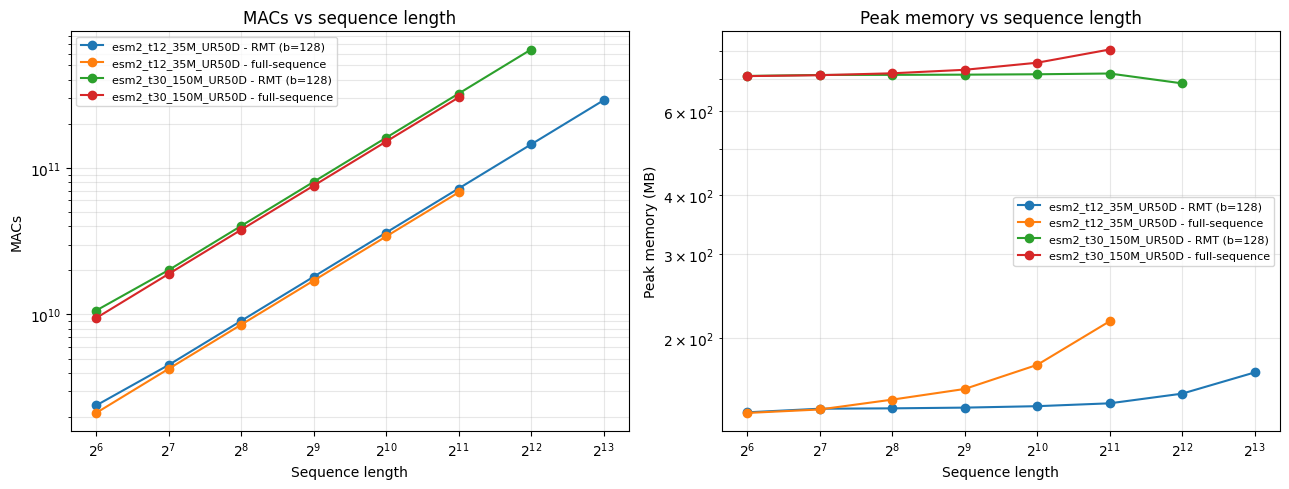

In [7]:
results1 = run_extended_cost_sweep(block_size=128)
save_and_plot(results1)


Loading facebook/esm2_t12_35M_UR50D...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Variant            | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
--------------------------------------------------------------------
full-sequence      | 64       | 2127437568     | 708.80            
full-sequence      | 128      | 4254644736     | 711.16            
full-sequence      | 256      | 8509059072     | 716.81            
full-sequence      | 512      | 17017887744    | 725.30            
full-sequence      | 1024     | 34035545088    | 744.15            
full-sequence      | 2048     | 68070859776    | 785.85            
full-sequence      | 4096     | OOM            | OOM               
full-sequence      | 8192     | OOM            | OOM               
RMT (b=64)         | 64       | 2393108064     | 709.21            
RMT (b=64)         | 128      | 4786216128     | 709.35            
RMT (b=64)         | 256      | 9572432256     | 709.61            
RMT (b=64)         | 512      | 19144864512    | 710.14            
RMT (b=64)         | 1024     | 38289729024    

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Variant            | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
--------------------------------------------------------------------
full-sequence      | 64       | 9450087424     | 709.59            
full-sequence      | 128      | 18899765248    | 712.73            
full-sequence      | 256      | 37799120896    | 719.33            
full-sequence      | 512      | 75597832192    | 731.58            
full-sequence      | 1024     | 151195254784   | 757.03            
full-sequence      | 2048     | 302390099968   | 806.98            
full-sequence      | 4096     | OOM            | OOM               
full-sequence      | 8192     | OOM            | OOM               
RMT (b=64)         | 64       | 10630887552    | 710.14            
RMT (b=64)         | 128      | 21261775104    | 710.32            
RMT (b=64)         | 256      | 42523550208    | 710.67            
RMT (b=64)         | 512      | 85047100416    | 711.38            
RMT (b=64)         | 1024     | 170094200832   

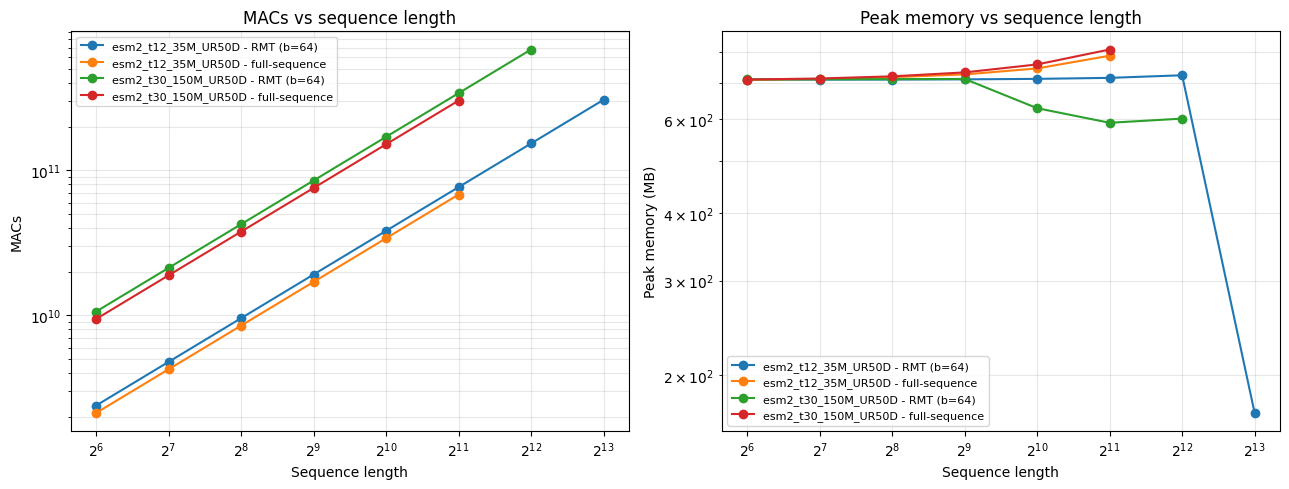

In [8]:
results2 = run_extended_cost_sweep(block_size=64)
save_and_plot(results2)

In [ ]:
results3 = run_extended_cost_sweep(block_size=32)
save_and_plot(results3)

In [ ]:
results4 = run_extended_cost_sweep(block_size=16)
save_and_plot(results4)

In [ ]:
results5 = run_extended_cost_sweep(block_size=8)
save_and_plot(results5)

#### A little bit focusing on biological aspects:

The most reasonable block size for chopping protein sequences depends on your specific application, but a length of 3 to 7 amino acids is ideal for sequence pattern matching (k-mers), while 50 to 150 amino acids is ideal for structural or functional domain analysis.
Choosing the right size requires balancing biological meaning with computational complexity.
#### Summary of Block Sizes

| Application | Block Size (Length) | Why This Size? |
|---|---|---|
| Motifs & K-mers | 3 – 7 amino acids | Captures highly conserved functional sites and local patterns without losing statistical significance. |
| Epitope Prediction | 8 – 15 amino acids | Matches the exact physical length of peptides that bind to MHC I and MHC II immune receptors. |
| Structural Domains | 50 – 150 amino acids | Captures independently folding, evolutionary stable structural and functional units of proteins. |

------------------------------
#### 1. Short Blocks: 3 to 7 Amino Acids (Motifs & K-mers)

* Mathematical space: The protein alphabet has 20 letters. A block size of k creates $20^k$ possible combinations.
* Why 3 is the lower limit: A size of 3 (20³ = 8,000 combinations) or 4 (20⁴ = 160,000 combinations) is excellent for finding short, local patterns like phosphorylation sites.
* The random match problem: If your blocks are too short (e.g., 2 amino acids), they will appear everywhere purely by random chance (20² = 400 combinations), rendering them biologically meaningless.
* The sparsity problem: If you choose a size higher than 7 (20⁷ = 1.28 × 10⁹ combinations), the sequence space becomes so vast that you will rarely find exact matches between different proteins.

#### 2. Medium Blocks: 8 to 15 Amino Acids (Immunology & Peptides)

* Biological binding: This range is the precise size used by the immune system to recognize foreign proteins.
* MHC complexes: T-cells recognize linear peptide fragments of 8–11 amino acids (MHC Class I) or 13–17 amino acids (MHC Class II).
* Machine learning: If you are building models for vaccine design or immunotherapy, slicing sequences into overlapping 9-mers (sliding window of 9, step of 1) is the standard industry benchmark.

#### 3. Long Blocks: 50 to 150 Amino Acids (Structural Domains)

* Autonomous folding: Proteins are naturally modular. A domain is a self-stabilizing segment that folds independently of the rest of the protein chain.
* Evolutionary conservation: Nature shuffles these larger blocks around to create new proteins. Slicing at this scale allows you to identify functional building blocks (like kinase domains or zinc fingers).

In [ ]:
results6 = run_extended_cost_sweep(block_size=3)
save_and_plot(results6)

## Accuracy Comparision

## Ablation Study to find effective vs ineffective instructions and model blocks